In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [23]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/FruitinAmazon.zip"

EXTRACT_DIR = "./fruitnamazon_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR}'")

File 'FruitinAmazon.zip' unzipped to './fruitnamazon_dataset'


##Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

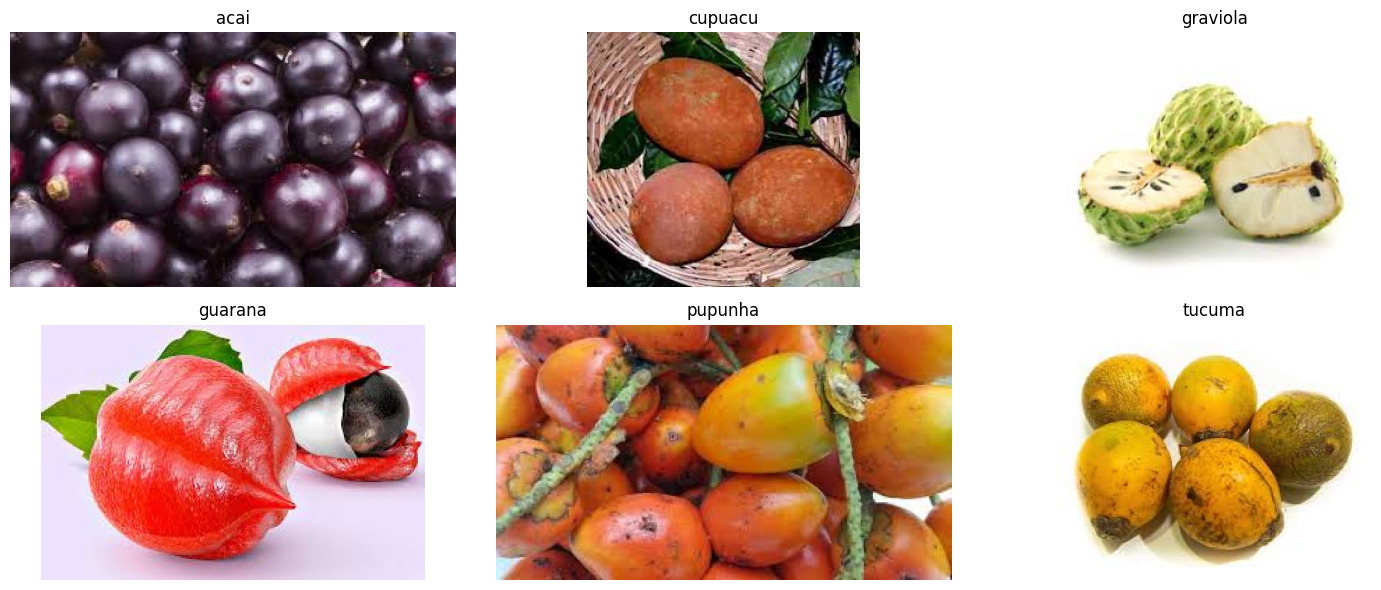

In [24]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/fruitnamazon_dataset/FruitinAmazon/train"
test_dir = "/content/fruitnamazon_dataset/FruitinAmazon/test"

# finds list of folder and each folder is class, folder
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# calculates how many columns we need to fit all classes into exactly 2 rows
num_classes = len(class_names)
cols = (num_classes + 1) // 2  # Calculate columns needed for 2 rows
plt.figure(figsize=(15, 6))

# Random Selection Loop and plots
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check for Broken Image:

In [25]:

corrupted_images = []

# Iterate through each class subdirectory
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Attempt to load and verify the image
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            # If corrupted, remove and record
            print(f"Removed corrupted image: {image_path}")
            os.remove(image_path)
            corrupted_images.append(image_path)


if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"Cleaned up {len(corrupted_images)} images.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [26]:
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

#Pixel values are 0–255, dividing by 255 brings them to 0–1.
rescale = tf.keras.layers.Rescaling(1./255)

# 3. Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',     #tells label to use subfolder names
    label_mode='int', #Encode labels as integers, Required for sparse_categorical_crossentropy.
    image_size=(img_height, img_width),
    interpolation='nearest', #When resizing, fill new pixels by copying the nearest original pixel. Simple and fast.
    batch_size=batch_size,
    shuffle=True, #Randomise order every epoch so the model doesn't learn class order instead of patterns.
    validation_split=validation_split,
    subset='training', #This call gets the 80% training portion. The val_ds call below gets the other 20%
    seed=123 #guarantes the same 80/20 split every time, no image appears in both.
)

# 4. Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # Validation should not be shuffled
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# 5. Apply Normalization to both
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("\nDatasets are loaded and normalized!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Datasets are loaded and normalized!


In [27]:
from tensorflow.keras import layers, models

#  lists everything inside the train folder
#  filters to folders only
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"Building model for {num_classes} classes: {class_names}\n")


# Build the Sequential Model
model = models.Sequential([

    # Convolutional Architecture

    # Convolutional Layer 1
    # create 32 filters, producing 32 feature maps. Each filter learns a different pattern — edges, curves,
    # each filter is a 3×3 grid of learnable numbers sliding across the image.
    # move the filter one pixel at a time horizontally and vertically.
    # adds zeros around the border so output spatial size = input spatial size
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu', input_shape=(128, 128, 3)),

    #window that slides across the feature map taking the maximum value from each 2×2 region.
    # jumps 2 pixels each time, so windows don't overlap. This is what halves the spatial size.
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # --- Fully Connected Network Architecture ---
    layers.Flatten(),

    # Hidden Layer 1 (64 neurons)
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (128 neurons)
    layers.Dense(128, activation='relu'),

    # Output Layer
    # one neuron per fruit class.
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Building model for 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Model Compilation and Train

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model.compile(
    optimizer='adam', #tells Keras how to update weights during backward propagation
    loss='sparse_categorical_crossentropy', #  labels are integers
    metrics=['accuracy']
)


# ModelCheckpoint saves the best version based on validation loss
checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_loss',
    save_best_only=True, #Only overwrite best_fruit_model.h5 when val_loss improves. Without this, every epoch overwrites the file
    verbose=1 # Print a message when the model is saved
)

# EarlyStopping stops training if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)



Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.1453 - loss: 2.0603
Epoch 1: val_loss improved from None to 2.70461, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 404ms/step - accuracy: 0.1389 - loss: 2.1968 - val_accuracy: 0.0556 - val_loss: 2.7046
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.2616 - loss: 1.7314
Epoch 2: val_loss improved from 2.70461 to 1.74980, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.2222 - loss: 1.7570 - val_accuracy: 0.0556 - val_loss: 1.7498
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.2332 - loss: 1.7166
Epoch 3: val_loss improved from 1.74980 to 1.63116, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 373ms/step - accuracy: 0.2778 - loss: 1.7067 - val_accuracy: 0.2222 - val_loss: 1.6312
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.3241 - loss: 1.5316
Epoch 4: val_loss did not improve from 1.63116
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.3472 - loss: 1.4977 - val_accuracy: 0.1111 - val_loss: 1.9019
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.5035 - loss: 1.2886
Epoch 5: val_loss did not improve from 1.63116
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.5417 - loss: 1.2898 - val_accuracy: 0.1111 - val_loss: 1.8456
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6429 - loss: 1.0631
Epoch 6: val_loss improved from 1.63116 to 1.41860, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.6944 - loss: 0.9903 - val_accuracy: 0.5000 - val_loss: 1.4186
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.8050 - loss: 0.7179
Epoch 7: val_loss improved from 1.41860 to 0.92729, saving model to best_fruit_model.h5


...


Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.8889 - loss: 0.4975 - val_accuracy: 0.6667 - val_loss: 0.8212
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9456 - loss: 0.2888
Epoch 9: val_loss improved from 0.82123 to 0.56779, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 463ms/step - accuracy: 0.9306 - loss: 0.3160 - val_accuracy: 0.8889 - val_loss: 0.5678
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9797 - loss: 0.1949
Epoch 10: val_loss did not improve from 0.56779
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 404ms/step - accuracy: 0.9861 - loss: 0.1911 - val_accuracy: 0.6667 - val_loss: 0.6277
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9497 - loss: 0.1735
Epoch 11: val_loss improved from 0.56779 to 0.51832, saving model to best_fruit_model.h5



Epoch 11: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 0.9583 - loss: 0.1580 - val_accuracy: 0.8333 - val_loss: 0.5183
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9902 - loss: 0.0699
Epoch 12: val_loss did not improve from 0.51832
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.9861 - loss: 0.0707 - val_accuracy: 0.8889 - val_loss: 0.7286
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9595 - loss: 0.1578
Epoch 13: val_loss improved from 0.51832 to 0.44410, saving model to best_fruit_model.h5



Epoch 13: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.9722 - loss: 0.1434 - val_accuracy: 0.8333 - val_loss: 0.4441
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 1.0000 - loss: 0.0307
Epoch 14: val_loss did not improve from 0.44410
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 1.0000 - loss: 0.0380 - val_accuracy: 0.8333 - val_loss: 0.6376
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 1.0000 - loss: 0.0627
Epoch 15: val_loss did not improve from 0.44410
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 1.0000 - loss: 0.0640 - val_accuracy: 0.7778 - val_loss: 0.4618
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9902 - loss: 0.0322
Epoch 16: val_loss improved from 0.44410 to 0.20298, saving model to best_fruit_model.h5



Epoch 16: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.9861 - loss: 0.0344 - val_accuracy: 0.8889 - val_loss: 0.2030
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9902 - loss: 0.0506
Epoch 17: val_loss did not improve from 0.20298
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - accuracy: 0.9861 - loss: 0.0520 - val_accuracy: 0.9444 - val_loss: 0.2335
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 1.0000 - loss: 0.0112
Epoch 18: val_loss did not improve from 0.20298
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 0.9444 - val_loss: 0.3240
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 1.0000 - loss: 0.0058
Epoch 19: val_loss did not improve from 0.20298
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.8333 - val_loss: 0.4904
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 1.0000 - loss: 0.0

Task 5: Evaluate the Model

In [29]:
#Evaluate the Model
print("\nFinal Evaluation on Validation Set")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")


Final Evaluation on Validation Set
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8889 - loss: 0.2030
Loss: 0.2030, Accuracy: 0.8889


# Task 6: Save and Load the Model

In [30]:
from tensorflow.keras.models import load_model

model.save('final_fruit_model.h5')
print("Model saved successfully as 'final_fruit_model.h5'")

loaded_model = load_model('best_fruit_model.h5')
print("Best version of the model reloaded successfully!")

#Re-evaluate to prove it works
re_loss, re_acc = loaded_model.evaluate(val_ds)
print(f"Reloaded Model Accuracy: {re_acc*100:.2f}%")

Model saved successfully as 'final_fruit_model.h5'


Best version of the model reloaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.8889 - loss: 0.2030
Reloaded Model Accuracy: 88.89%


# Task 7: Predictions and Classification Report

In [31]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# 1. Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='int',
    shuffle=False
)

# 2. Normalise test data
rescale = tf.keras.layers.Rescaling(1./255)
test_ds_scaled = test_ds.map(lambda x, y: (rescale(x), y))

# 3. Extract ground truth and predictions
y_true = []
y_pred_probs = []

print("Generating predictions on test set...")
for images, labels in test_ds_scaled:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get class names from test folder
class_names = sorted([
    d for d in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, d))
])

# 5. Generate report for all 6 classes
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("\n--- FINAL CLASSIFICATION REPORT (TEST SET) ---")
print(report)

Found 30 files belonging to 6 classes.
Generating predictions on test set...

--- FINAL CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.50      1.00      0.67         5
     guarana       0.62      1.00      0.77         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.69      0.73      0.67        30
weighted avg       0.69      0.73      0.67        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
